# Dropping Buoys - Repeated Relativistic Boosts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lookbusy1344/Relativity/blob/main/Python/Dropping_buoys.ipynb)

A spaceship leaves Earth and accelerates to $0.5c$. The crew drop a buoy - a small beacon that drifts freely in space - and immediately accelerate to $0.5c$ **relative to that buoy**. They drop another buoy and do it again. And again.

From inside the ship, every boost is *identical*. The crew always accelerate to $0.5c$ relative to their immediate surroundings. There is no sense of accumulation, no extra effort required, no alarm that sounds. The laws of physics are the same in every inertial frame, so each boost looks and feels exactly like the first.

The buoys form a chain of reference frames, each moving at $0.5c$ relative to its neighbour:

$$\text{Earth} \xrightarrow{\;0.5c\;} \text{Buoy 1} \xrightarrow{\;0.5c\;} \text{Buoy 2} \xrightarrow{\;0.5c\;} \cdots \xrightarrow{\;0.5c\;} \text{Buoy } 23$$

Each arrow is a *relative* velocity between adjacent frames. The question is: what does Earth observe?

In [1]:
# Download relativity_lib.py if not present (important for Google Colab)
import os

if not os.path.exists("relativity_lib.py"):
    !wget -q https://raw.githubusercontent.com/lookbusy1344/Relativity/main/Python/relativity_lib.py

import matplotlib.pyplot as plt
import mpmath as mp
import relativity_lib as rl
from prettytable import PrettyTable, TableStyle
from IPython.display import Markdown

rl.configure(100)  # 100 decimal places of precision throughout

NUM_BUOYS = 23
BOOST_FRACTION = rl.ensure("0.5")  # 0.5c per boost, in proper frame
BOOST_VELOCITY = rl.c * BOOST_FRACTION  # in m/s
GALAXY_LY = rl.ensure("100000")  # Milky Way diameter, light-years

print(f"Boost per step (proper frame): {float(BOOST_FRACTION)}c")
print(f"Number of buoys to drop:       {NUM_BUOYS}")

Boost per step (proper frame): 0.5c
Number of buoys to drop:       23


## The crew's point of view

At every stage the ship's crew repeat the same manoeuver:

1. Drop a buoy — at the moment of release the ship and buoy are at rest relative to each other
2. Fire engines, accelerating to $0.5c$ relative to that buoy — the buoy now recedes at $0.5c$ behind the ship
3. Repeat

Nothing changes from one boost to the next. The crew never experience anything that could tell them they are doing something different or harder than before. This is a direct consequence of the *equivalence of inertial frames*: there is no experiment you can perform inside the ship to determine your absolute speed.

## What Earth sees - relativistic velocity addition

Earth's perspective is more constrained. Velocities do not add naively across inertial frames. The correct formula is:

$$v_{\text{combined}} = \frac{v_1 + v_2}{1 + \dfrac{v_1 v_2}{c^2}} \tag{1}$$

Each time the crew boost by $0.5c$ in their current frame, Earth applies equation (1) to find the new coordinate velocity. The denominator keeps the result strictly below $c$, no matter how many boosts occur.


In [2]:
# Build up Earth-frame velocity, one boost at a time.
# Each boost adds 0.5c in the current proper frame; rl.add_velocities() applies equation (1).

earth_frame_velocities = []
current_vel = rl.ensure("0")  # ship starts at rest relative to Earth

for _ in range(NUM_BUOYS):
    current_vel = rl.add_velocities(current_vel, BOOST_VELOCITY)
    earth_frame_velocities.append(current_vel)

earth_frame_fractions = [v / rl.c for v in earth_frame_velocities]

# What naive Newtonian physics would predict
naive_final_c = BOOST_FRACTION * NUM_BUOYS

print(f"Newtonian (wrong):   {float(naive_final_c):.1f}c  - faster than light!")
print(
    f"Relativistic:        {rl.format_mpf_significant(earth_frame_fractions[-1], 6, '9')}c"
)

Newtonian (wrong):   11.5c  - faster than light!
Relativistic:        0.9999999999787557c


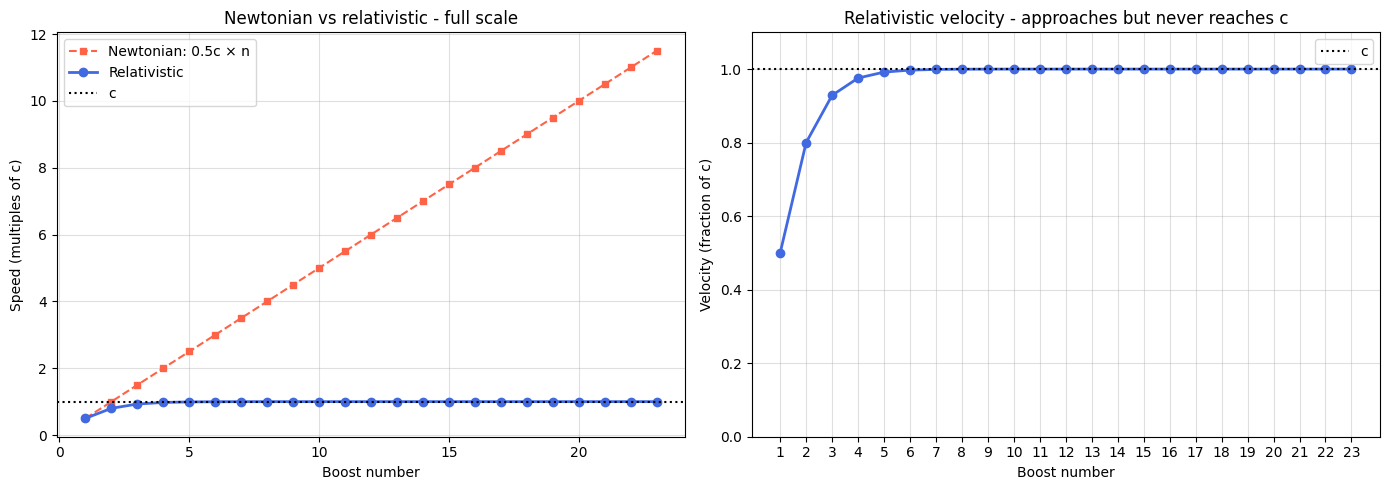

In [3]:
boost_nums = list(range(1, NUM_BUOYS + 1))
earth_fracs_float = [float(f) for f in earth_frame_fractions]
naive_fracs = [float(BOOST_FRACTION) * n for n in boost_nums]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: full scale - Newtonian vs relativistic
ax1.plot(
    boost_nums,
    naive_fracs,
    "s--",
    color="tomato",
    linewidth=1.5,
    markersize=5,
    label="Newtonian: 0.5c × n",
)
ax1.plot(
    boost_nums,
    earth_fracs_float,
    "o-",
    color="royalblue",
    linewidth=2,
    markersize=6,
    label="Relativistic",
)
ax1.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Speed (multiples of c)")
ax1.set_title("Newtonian vs relativistic - full scale")
ax1.legend()
ax1.grid(True, alpha=0.4)

# Right: zoom in on the relativistic curve
ax2.plot(
    boost_nums, earth_fracs_float, "o-", color="royalblue", linewidth=2, markersize=6
)
ax2.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Velocity (fraction of c)")
ax2.set_title("Relativistic velocity - approaches but never reaches c")
ax2.legend()
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show();

The left panel makes the contrast stark. Newtonian physics has the ship exceeding $c$ after just two boosts. The relativistic curve flattens instead, each successive boost contributing less and less to the coordinate velocity as seen from Earth.

## Rapidity - why each boost truly is identical

*Rapidity* $\phi$ is the natural measure of relativistic motion. It is defined as:

$$\phi = \tanh^{-1}\!\left(\frac{v}{c}\right) \tag{2}$$

Unlike coordinate velocity, rapidities add *linearly*. When you boost by $0.5c$ in your current frame you always add exactly $\phi_{0.5c}$ to your rapidity - regardless of how fast you were already going. After $n$ identical boosts:

$$\phi_n = n \cdot \phi_{0.5c} \tag{3}$$

This is the mathematical confirmation of what the crew experience: each boost is genuinely the same operation. The ship's rapidity is a running total that grows at a constant rate, one step per buoy. To recover the coordinate velocity for a given observer, convert back via:

$$v = c \cdot \tanh(\phi_n) \tag{4}$$

Because $\tanh$ maps all of $\mathbb{R}$ into $(-1, 1)$, rapidity can grow without bound - perform ten thousand boosts if you like - yet the coordinate velocity asymptotically approaches $c$ and never reaches it.

In [4]:
# Rapidity of a single 0.5c boost
rap_single = rl.rapidity_from_velocity(BOOST_VELOCITY)
print(f"Rapidity of one 0.5c boost: {float(rap_single):.6f}")
print(f"(Each subsequent boost adds exactly this much - no accumulation, no friction)")
print()

# Total rapidity and velocity after each boost, via simple multiplication
rapidities = [rap_single * rl.ensure(str(n)) for n in range(1, NUM_BUOYS + 1)]
velocities_from_rap = [rl.velocity_from_rapidity(r) for r in rapidities]
fractions_from_rap = [v / rl.c for v in velocities_from_rap]

# Verify both methods agree to many decimal places
max_diff = max(
    abs(float(f1 - f2)) for f1, f2 in zip(earth_frame_fractions, fractions_from_rap)
)
print(f"Max difference vs velocity-addition method: {max_diff:.2e}  (rounding only)")

Rapidity of one 0.5c boost: 0.549306
(Each subsequent boost adds exactly this much - no accumulation, no friction)

Max difference vs velocity-addition method: 1.43e-101  (rounding only)


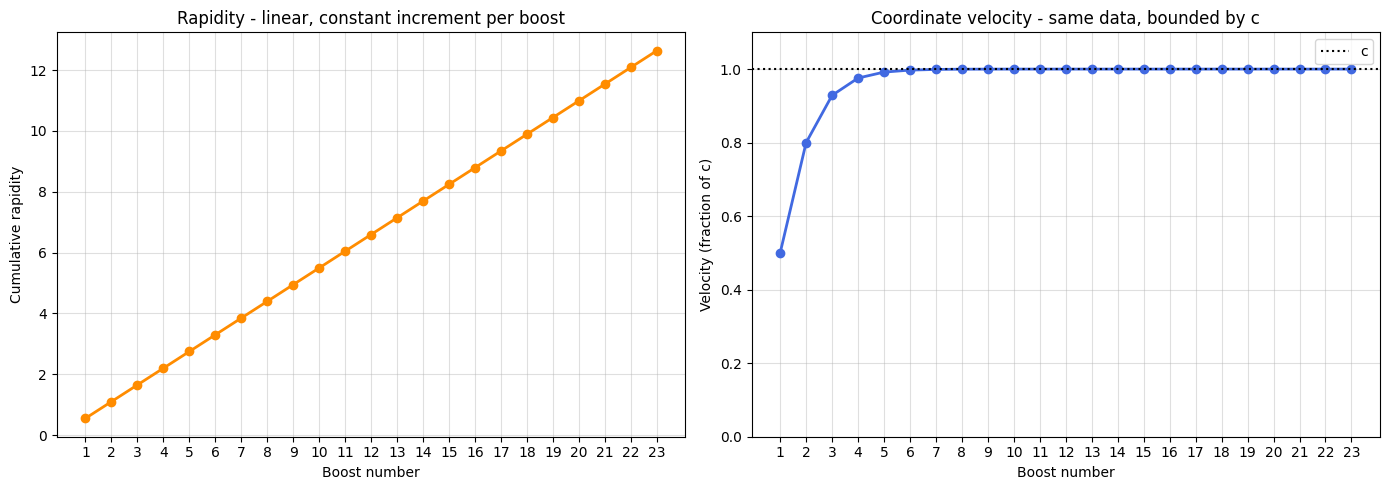

In [5]:
rapidities_float = [float(r) for r in rapidities]
fracs_float = [float(f) for f in fractions_from_rap]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: rapidity grows linearly - each boost is identical
ax1.plot(
    boost_nums, rapidities_float, "o-", color="darkorange", linewidth=2, markersize=6
)
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Cumulative rapidity")
ax1.set_title("Rapidity - linear, constant increment per boost")
ax1.grid(True, alpha=0.4)
ax1.set_xticks(boost_nums)

# Right: velocity curves toward c
ax2.plot(boost_nums, fracs_float, "o-", color="royalblue", linewidth=2, markersize=6)
ax2.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Velocity (fraction of c)")
ax2.set_title("Coordinate velocity - same data, bounded by c")
ax2.legend()
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show();

The left panel is the crew's reality: a straight line, constant slope, same boost every time. The right panel is what an external observer computes: the same data, compressed by the $\tanh$ function into a curve that never quite touches $c$.

Both panels describe the same physical events. The difference is only in which coordinate system you use to describe them.

## Length contraction - the galaxy from each buoy's frame

Every buoy is at rest in its own inertial frame. From buoy $n$'s perspective, the Milky Way is rushing past at the buoy's coordinate velocity $v_n$. Distances in the direction of motion are contracted by the Lorentz factor:

$$\gamma = \frac{1}{\sqrt{1 - v^2/c^2}} \tag{5}$$

The galaxy's 100,000 light-year width shrinks to:

$$L_{\text{buoy}} = \frac{L_0}{\gamma} \tag{6}$$

Each successive buoy has a higher $\gamma$ and sees a more compressed galaxy. By the time we reach buoy 23, the Milky Way is a thin disc from that frame's point of view.

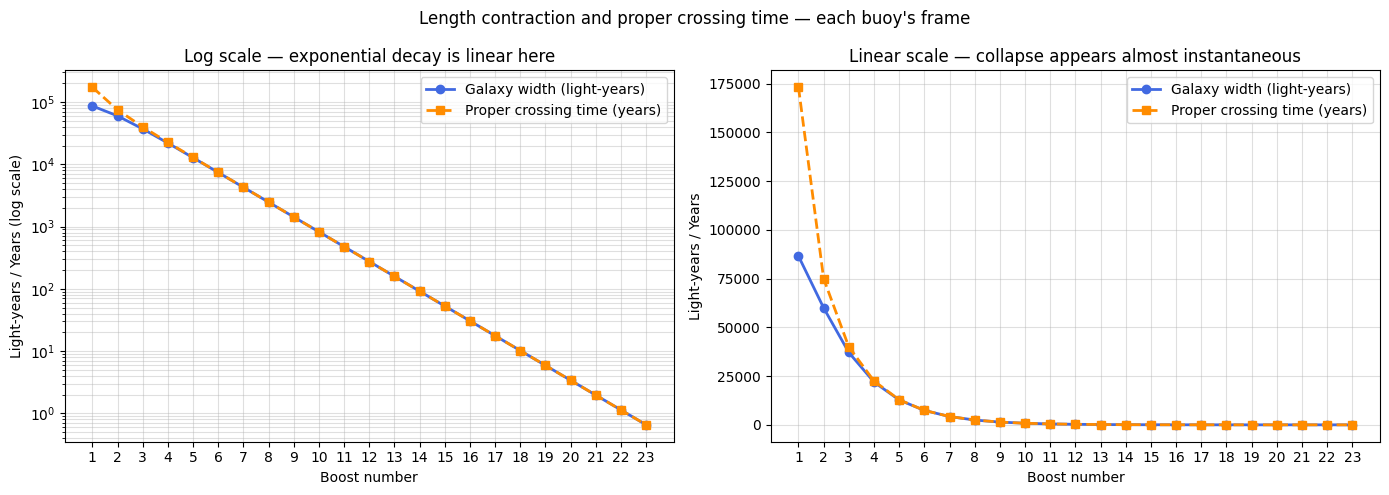

In [6]:
# Galaxy width (contracted) and proper crossing time from each buoy's frame
galaxy_widths_ly = []
transit_times_yr = []

for n in range(1, NUM_BUOYS + 1):
    rapidity = rap_single * rl.ensure(str(n))
    velocity = rl.velocity_from_rapidity(rapidity)
    fraction = velocity / rl.c  # v/c, dimensionless
    gamma = rl.lorentz_factor(velocity)
    width = GALAXY_LY / gamma  # contracted width in light-years
    # Proper time = contracted distance / buoy's velocity (ly / (v/c) = years since c=1ly/yr)
    transit = width / fraction
    galaxy_widths_ly.append(float(width))
    transit_times_yr.append(float(transit))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, log in ((ax1, True), (ax2, False)):
    if log:
        ax.semilogy(
            boost_nums,
            galaxy_widths_ly,
            "o-",
            color="royalblue",
            linewidth=2,
            markersize=6,
            label="Galaxy width (light-years)",
        )
        ax.semilogy(
            boost_nums,
            transit_times_yr,
            "s--",
            color="darkorange",
            linewidth=2,
            markersize=6,
            label="Proper crossing time (years)",
        )
        ax.set_title("Log scale — exponential decay is linear here")
        ax.set_ylabel("Light-years / Years (log scale)")
        ax.grid(True, alpha=0.4, which="both")
    else:
        ax.plot(
            boost_nums,
            galaxy_widths_ly,
            "o-",
            color="royalblue",
            linewidth=2,
            markersize=6,
            label="Galaxy width (light-years)",
        )
        ax.plot(
            boost_nums,
            transit_times_yr,
            "s--",
            color="darkorange",
            linewidth=2,
            markersize=6,
            label="Proper crossing time (years)",
        )
        ax.set_title("Linear scale — collapse appears almost instantaneous")
        ax.set_ylabel("Light-years / Years")
        ax.grid(True, alpha=0.4)
    ax.set_xlabel("Boost number")
    ax.legend()
    ax.set_xticks(boost_nums)

plt.suptitle("Length contraction and proper crossing time — each buoy's frame")
plt.tight_layout()
plt.show();

### Effective acceleration is unbounded

Length contraction has a striking consequence for the crew. From inside the ship, the galaxy is not 100,000 light-years wide — it is $L_0 / \gamma$, and that distance shrinks with every boost. The destination is literally getting closer. What looks like asymptotic crawl from Earth's frame is, from the crew's frame, an ever-compressing journey.

The right quantity to track here is *proper velocity* — coordinate distance per unit of proper time:

$$w = \gamma v = c \sinh(\phi) \tag{7}$$

Unlike coordinate velocity, proper velocity has no upper bound. Because rapidity $\phi$ grows linearly with boost count ($\phi_n = n \phi_0$), proper velocity grows as $\sinh(n \phi_0)$, which is exponential in $n$. Each boost adds the same rapidity increment, and each rapidity increment multiplies the effective ground-covering speed by a constant factor.

The practical implication: a traveller can cross arbitrarily large distances in arbitrarily short proper time, simply by boosting enough times. Earth assigns a coordinate velocity that never quite reaches $c$. The traveller experiences a destination that keeps rushing toward them, covering tens of thousands of light-years per year of personal time after enough boosts. There is no ceiling on this — proper velocity is unbounded, and so is the effective rate of traversal across the universe.

None of this involves approaching $c$ in the ship's own frame — which would be impossible anyway. The speed of light is $c$ in every inertial frame by definition, including the ship's. The crew can never measure light moving at anything other than $c$ relative to themselves, regardless of how many boosts they have performed. What changes is not their speed relative to light, but the contracted scale of the universe around them: the galaxy gets shorter, the journey gets faster, and the stars compress toward a single point ahead — all while light continues to race past at exactly $c$.

## Table of all 23 boosts

In [7]:
table = PrettyTable(
    [
        "Buoy",
        "Rapidity",
        "Velocity (c)",
        "Lorentz γ",
        "Galaxy width (ly)",
        "Transit time (yr)",
    ]
)
table.set_style(TableStyle.MARKDOWN)
table.align = "r"

for n in range(1, NUM_BUOYS + 1):
    rapidity = rap_single * rl.ensure(str(n))
    velocity = rl.velocity_from_rapidity(rapidity)
    fraction = velocity / rl.c
    gamma = rl.lorentz_factor(velocity)
    galaxy_width = GALAXY_LY / gamma
    # Proper time for this buoy to cross the contracted galaxy at its velocity
    transit_years = galaxy_width / fraction

    table.add_row(
        [
            str(n),
            rl.format_mpf_significant(rapidity, 4),
            rl.format_mpf_significant(fraction, 4, "9"),
            rl.format_mpf(gamma, 2),
            rl.format_mpf(galaxy_width, 1),
            rl.format_mpf(transit_years, 1),
        ]
    )

display(Markdown(table.get_string()));

| Buoy | Rapidity |     Velocity (c) |  Lorentz γ | Galaxy width (ly) | Transit time (yr) |
|----: |--------: |----------------: |----------: |-----------------: |-----------------: |
|    1 |   0.5493 |              0.5 |       1.15 |          86,602.5 |         173,205.0 |
|    2 |  1.09861 |              0.8 |       1.66 |          60,000.0 |          75,000.0 |
|    3 |   1.6479 |          0.92857 |       2.69 |          37,115.3 |          39,970.4 |
|    4 |   2.1972 |          0.97560 |       4.55 |          21,951.2 |          22,500.0 |
|    5 |   2.7465 |         0.991803 |       7.82 |          12,777.4 |          12,883.0 |
|    6 |   3.2958 |         0.997260 |      13.51 |           7,397.2 |           7,417.5 |
|    7 |   3.8451 |        0.9990859 |      23.39 |           4,274.7 |           4,278.6 |
|    8 |   4.3944 |        0.9996952 |      40.50 |           2,468.7 |           2,469.5 |
|    9 |   4.9437 |        0.9998983 |      70.15 |           1,425.4 |           1,425.6 |
|   10 |   5.4930 |       0.99996613 |     121.50 |             823.0 |             823.0 |
|   11 |  6.04236 |       0.99998871 |     210.44 |             475.1 |             475.1 |
|   12 |   6.5916 |      0.999996236 |     364.50 |             274.3 |             274.3 |
|   13 |   7.1409 |      0.999998745 |     631.33 |             158.3 |             158.3 |
|   14 |   7.6902 |     0.9999995818 |   1,093.50 |              91.4 |              91.4 |
|   15 |   8.2395 |     0.9999998606 |   1,893.99 |              52.7 |              52.7 |
|   16 |   8.7888 |    0.99999995353 |   3,280.50 |              30.4 |              30.4 |
|   17 |   9.3382 |    0.99999998451 |   5,681.99 |              17.5 |              17.5 |
|   18 |   9.8875 |   0.999999994837 |   9,841.50 |              10.1 |              10.1 |
|   19 |  10.4368 |   0.999999998279 |  17,045.97 |               5.8 |               5.8 |
|   20 |  10.9861 |  0.9999999994264 |  29,524.50 |               3.3 |               3.3 |
|   21 |  11.5354 |  0.9999999998088 |  51,137.93 |               1.9 |               1.9 |
|   22 | 12.08473 | 0.99999999993626 |  88,573.50 |               1.1 |               1.1 |
|   23 |  12.6340 | 0.99999999997875 | 153,413.80 |               0.6 |               0.6 |

## The final state - summary

In [8]:
# Final state after all 23 boosts, computed directly via rapidity
tot_rap = rap_single * rl.ensure(str(NUM_BUOYS))
tot_vel = rl.velocity_from_rapidity(tot_rap)
tot_fraction = tot_vel / rl.c
lorentz = rl.lorentz_factor(tot_vel)
galaxy_contracted = GALAXY_LY / lorentz

print(f"Total rapidity after {NUM_BUOYS} boosts:    {float(tot_rap):.6f}")
print(
    f"Velocity in Earth frame:         {rl.format_mpf_significant(tot_fraction, 8, '9')}c"
)
print(f"Lorentz factor γ:                {rl.format_mpf(lorentz, 2)}")
print(
    f"Galaxy width in buoy-23 frame:   {rl.format_mpf(galaxy_contracted, 2)} light-years"
)

Total rapidity after 23 boosts:    12.634041
Velocity in Earth frame:         0.999999999978755763c
Lorentz factor γ:                153,413.80
Galaxy width in buoy-23 frame:   0.65 light-years


## Energy, relativistic mass, and the rocket equation

Every discussion of relativistic travel eventually hits the same objection: *what about the fuel?* Each boost requires energy, and that energy has to come from somewhere.

### Relativistic energy

The total energy of a moving object is:

$$E = \gamma m c^2 \tag{7}$$

At rest ($\gamma = 1$) this reduces to the famous $E = mc^2$. In motion, $\gamma > 1$ and the total energy is higher. After 23 boosts our ship has $\gamma \approx 153{,}414$, so from Earth's perspective it carries enormous energy - even for a small final payload mass.

The term *relativistic mass* ($\gamma m$) is sometimes used for this, though modern physics prefers to keep mass as a Lorentz invariant (rest mass $m$) and track the energy separately. The physics is identical either way.

> **In the ship's own proper frame, $\gamma = 1$ always.** The crew experience no relativistic mass, no time dilation, no length contraction. The ship feels perfectly normal. These effects are not properties of the ship - they are properties of *how other frames describe it*. In fact, $\gamma$ has a different value in every frame simultaneously: Earth assigns one value, each buoy assigns a different one, and the ship assigns 1 to itself. All of these are equally valid. It is only external observers who assign a large $\gamma$ and the enormous energy that comes with it.

### The photon rocket

A photon rocket is the theoretical optimum: matter-antimatter annihilation products are converted entirely into directed photons fired out the back at $c$. This gives an exhaust velocity of $v_e = c$ - the maximum physically possible - and the Tsiolkovsky rocket equation in rapidity form becomes:

$$\frac{m_0}{m_f} = \exp\!\left(\frac{\Delta\phi}{v_e/c}\right) = \exp(\Delta\phi) \tag{8}$$

For each boost of $0.5c$, the rapidity increment is $\Delta\phi = \tanh^{-1}(0.5) \approx 0.549$, giving a mass ratio of $e^{0.549} = \sqrt{3} \approx 1.73:1$. Roughly 42% of the ship's mass is consumed as fuel per boost.

In practice a photon rocket is extremely difficult to engineer - collimating gamma rays from annihilation into a coherent beam is a major unsolved problem. The companion *Antimatter rocket* notebook discusses the more realistic charged-pion drive, which achieves around 34% total system efficiency and has a significantly worse mass ratio. We use the photon rocket here as a best-case baseline.

> For a detailed treatment of antimatter propulsion - including the charged-pion drive, nozzle efficiency, and what it would actually take to cross the galaxy - see the [Antimatter rocket notebook](https://github.com/lookbusy1344/Relativity/blob/main/Python/Antimatter%20rocket.ipynb).

### Why later boosts still get cheaper

The mass ratio is the same for every boost, which means the ship retains the same *fraction* of its mass each time. Since the ship is lighter after every burn, the *absolute* fuel mass decreases with each successive boost.

Boost 1 is the most expensive. Boost 23 is the cheapest in absolute terms. The mass budget is heavily front-loaded.

The challenge of the rocket equation is not the individual boosts - it is the total initial mass required to carry enough fuel for *all* of them.

In [9]:
# Photon rocket: exhaust velocity = c (theoretical maximum)
ve_eff_frac = rl.one  # v_e / c = 1

# Relativistic Tsiolkovsky (rapidity form): m0/mf = exp(Δφ / (ve_eff/c)) = exp(Δφ)
# Δφ = rapidity of one 0.5c boost = rap_single; with ve_eff = c this simplifies to exp(rap_single) = sqrt(3)
mass_ratio_inv = mp.exp(rap_single / ve_eff_frac)  # m_before / m_after per boost
mass_remaining_frac = rl.one / mass_ratio_inv  # m_after / m_before per boost
fuel_fraction_pion = rl.one - mass_remaining_frac  # reused by fuel table below

print(f"Exhaust velocity:              c (photon rocket)")
print(
    f"Mass ratio per boost (m0/mf):  {rl.format_mpf(mass_ratio_inv, 4)}:1  (= sqrt(3))"
)
print(
    f"Fuel consumed per boost:       {rl.format_mpf(fuel_fraction_pion * rl.ensure('100'), 2)}% of ship mass"
)
print()

# To deliver 1 kg of payload after all 23 boosts
payload_kg = rl.ensure("1")
initial_mass = payload_kg * (mass_ratio_inv ** rl.ensure(str(NUM_BUOYS)))

print(f"To deliver {rl.format_mpf(payload_kg, 0)} kg after {NUM_BUOYS} boosts:")
print(f"  Required initial mass: {rl.format_mpf(initial_mass, 1)} kg")
print()

# Absolute fuel burned per boost, normalised to initial_mass = 1 (all mpf)
remaining_all = [mass_remaining_frac ** rl.ensure(str(n)) for n in range(NUM_BUOYS + 1)]
fuel_each = [remaining_all[n] - remaining_all[n + 1] for n in range(NUM_BUOYS)]
remaining_after = remaining_all[1:]  # mass fraction remaining after boost n

print(f"Boost  1 burns {rl.format_mpf_significant(fuel_each[0], 4)} x initial mass")
print(f"Boost 23 burns {mp.nstr(fuel_each[-1], 2)} x initial mass")
print(
    f"Boost 23 costs {rl.format_mpf_significant(fuel_each[-1] / fuel_each[0] * rl.ensure('100'), 4)}% as much as boost 1"
)

Exhaust velocity:              c (photon rocket)
Mass ratio per boost (m0/mf):  1.7320:1  (= sqrt(3))
Fuel consumed per boost:       42.26% of ship mass

To deliver 1 kg after 23 boosts:
  Required initial mass: 306,827.6 kg

Boost  1 burns 0.4226 x initial mass
Boost 23 burns 2.4e-6 x initial mass
Boost 23 costs 0.0005645% as much as boost 1


In [10]:
fuel_table = PrettyTable(
    [
        "Boost",
        "Fuel this boost (% of current mass)",
        "Fuel this boost (% of initial mass)",
        "Cumulative fuel used (% of initial)",
        "Remaining mass (% of initial)",
    ]
)
fuel_table.set_style(TableStyle.MARKDOWN)
fuel_table.align = "r"

cumulative_fuel = rl.ensure("0")
hundred = rl.ensure("100")

for n in range(1, NUM_BUOYS + 1):
    # Mass remaining before and after this boost (as mpf fractions of initial)
    before = mass_remaining_frac ** rl.ensure(str(n - 1))
    after = mass_remaining_frac ** rl.ensure(str(n))

    fuel_abs = before - after
    cumulative_fuel = cumulative_fuel + fuel_abs

    fuel_table.add_row(
        [
            str(n),
            rl.format_mpf(fuel_fraction_pion * hundred, 2),
            rl.format_mpf_significant(fuel_abs * hundred, 4),
            rl.format_mpf_significant(cumulative_fuel * hundred, 6, "9"),
            rl.format_mpf_significant(after * hundred, 4),
        ]
    )

display(Markdown(fuel_table.get_string()));

| Boost | Fuel this boost (% of current mass) | Fuel this boost (% of initial mass) | Cumulative fuel used (% of initial) | Remaining mass (% of initial) |
|-----: |-----------------------------------: |-----------------------------------: |-----------------------------------: |-----------------------------: |
|     1 |                               42.26 |                             42.2649 |                           42.264973 |                       57.7350 |
|     2 |                               42.26 |                             24.4016 |                           66.666666 |                       33.3333 |
|     3 |                               42.26 |                            14.08832 |                           80.754991 |                       19.2450 |
|     4 |                               42.26 |                              8.1338 |                           88.888888 |                       11.1111 |
|     5 |                               42.26 |                              4.6961 |                           93.584997 |                        6.4150 |
|     6 |                               42.26 |                              2.7112 |                           96.296296 |                        3.7037 |
|     7 |                               42.26 |                              1.5653 |                           97.861665 |                        2.1383 |
|     8 |                               42.26 |                              0.9037 |                           98.765432 |                        1.2345 |
|     9 |                               42.26 |                              0.5217 |                           99.287221 |                        0.7127 |
|    10 |                               42.26 |                              0.3012 |                           99.588477 |                        0.4115 |
|    11 |                               42.26 |                              0.1739 |                           99.762407 |                        0.2375 |
|    12 |                               42.26 |                              0.1004 |                           99.862825 |                        0.1371 |
|    13 |                               42.26 |                             0.05797 |                          99.9208024 |                       0.07919 |
|    14 |                               42.26 |                             0.03347 |                          99.9542752 |                       0.04572 |
|    15 |                               42.26 |                             0.01932 |                          99.9736008 |                       0.02639 |
|    16 |                               42.26 |                             0.01115 |                          99.9847584 |                       0.01524 |
|    17 |                               42.26 |                            0.006441 |                         99.99120027 |                      0.008799 |
|    18 |                               42.26 |                            0.003719 |                         99.99491947 |                      0.005080 |
|    19 |                               42.26 |                            0.002147 |                         99.99706675 |                      0.002933 |
|    20 |                               42.26 |                            0.001239 |                         99.99830649 |                      0.001693 |
|    21 |                               42.26 |                           0.0007157 |                        99.999022252 |                     0.0009777 |
|    22 |                               42.26 |                           0.0004132 |                        99.999435497 |                     0.0005645 |
|    23 |                               42.26 |                           0.0002385 |                        99.999674084 |                     0.0003259 |

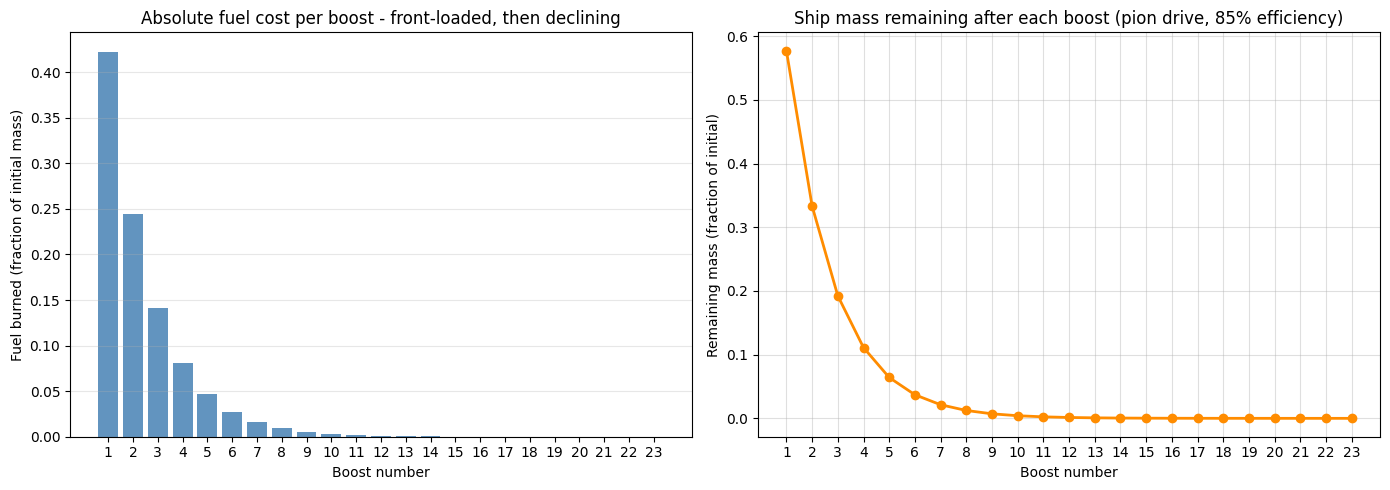

In [11]:
fuel_each_float = [float(f) for f in fuel_each]
remaining_after_float = [float(r) for r in remaining_after]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute fuel burned per boost (normalised to initial_mass = 1)
ax1.bar(boost_nums, fuel_each_float, color="steelblue", alpha=0.85)
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Fuel burned (fraction of initial mass)")
ax1.set_title("Absolute fuel cost per boost - front-loaded, then declining")
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_xticks(boost_nums)

# Right: remaining ship mass after each boost
ax2.plot(
    boost_nums,
    remaining_after_float,
    "o-",
    color="darkorange",
    linewidth=2,
    markersize=6,
)
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Remaining mass (fraction of initial)")
ax2.set_title("Ship mass remaining after each boost (pion drive, 85% efficiency)")
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)

plt.tight_layout()
plt.show();

## c is not a barrier

The most important thing to take from this scenario is what the crew *do not* experience.

At no point does the ship's behaviour change. Each boost is routine: check speed relative to the last buoy (zero), accelerate to $0.5c$, drop the next buoy. The crew feel the same thrust, reach the same relative speed, and repeat. The 23rd boost is indistinguishable from the 1st.

What changes is only how *other* frames describe the ship's motion:

- **Proper frame (crew)**: rapidity climbs at a constant rate. Each boost adds the same increment. This can continue indefinitely - there is no ceiling.
- **Earth's frame**: coordinate velocity asymptotically approaches $c$ but never reaches it. Each boost contributes a smaller and smaller increment to the coordinate speed.
- **Each buoy's frame**: the galaxy appears as an increasingly compressed disc. By buoy 23 it is a fraction of its rest-frame width.

The speed of light is not a wall. It is a limit that coordinate velocity asymptotically approaches from one side. Rapidity - the quantity that actually reflects what the crew experience - has no such limit. You can keep boosting forever.

### Later boosts are easier, not harder

Many people expect relativistic travel to become progressively more difficult as you approach $c$ - the intuition being that "relativistic mass" grows without bound and the ship becomes harder to accelerate. This intuition is wrong in the proper frame.

> Each boost burns the same *fraction* of the ship's remaining mass. Since the ship is lighter after every burn, the absolute fuel cost of each successive boost is *less* than the one before. Boost 23 costs a tiny fraction of what boost 1 costs in absolute terms. The rocket equation's challenge is front-loaded, not back-loaded.

The apparent difficulty of approaching $c$ exists only in coordinate descriptions from external frames. From inside the ship, acceleration is no harder at boost 23 than at boost 1. The increasing $\gamma$ assigned by Earth is not something the crew feel - it is a statement about geometry, not about engine effort.

---

*See also:*
[Rapidity](https://github.com/lookbusy1344/Relativity/blob/main/Python/Rapidity.ipynb) |
[Velocity adding](https://github.com/lookbusy1344/Relativity/blob/main/Python/Velocity%20adding.ipynb) |
[Time dilation](https://github.com/lookbusy1344/Relativity/blob/main/Python/Time%20dilation.ipynb) |
[Antimatter rocket](https://github.com/lookbusy1344/Relativity/blob/main/Python/Antimatter%20rocket.ipynb) |
[Interactive calculator](https://lookbusy1344.github.io/Relativity/)